In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("../data/processed/repos_clean.csv")

In [ ]:
!pip install sentence-transformers scikit-learn matplotlib seaborn -q

In [ ]:


# Cargar dataset procesado
df = pd.read_csv("data/processed/repos_clean.csv")

print(f"Dataset cargado: {df.shape}")
print(f"Columnas: {list(df.columns)}")

Dataset cargado: (3034, 15)
Columnas: ['repo_id', 'nombre', 'descripcion', 'lenguaje', 'stars', 'forks', 'topics', 'fecha_creacion', 'ultimo_commit', 'url', 'dias_sin_commit', 'antiguedad_dias', 'num_topics', 'ratio_forks_stars', 'stars_por_dia']


#verificar data

In [ ]:
print(f"Shape: {df.shape}")
print(f"Columnas: {df.columns.tolist()}")
print(df.head(3))

Shape: (3034, 15)
Columnas: ['repo_id', 'nombre', 'descripcion', 'lenguaje', 'stars', 'forks', 'topics', 'fecha_creacion', 'ultimo_commit', 'url', 'dias_sin_commit', 'antiguedad_dias', 'num_topics', 'ratio_forks_stars', 'stars_por_dia']
     repo_id                    nombre  \
0   45717250     tensorflow/tensorflow   
1  574523116            f/prompts.chat   
2  155220641  huggingface/transformers   

                                         descripcion lenguaje   stars  forks  \
0  An Open Source Machine Learning Framework for ...      C++  194936  75296   
1  f.k.a. Awesome ChatGPT Prompts. Share, discove...     HTML  161175  21050   
2  🤗 Transformers: the model-definition framework...   Python  160100  33058   

                                              topics  \
0  ['tensorflow', 'machine-learning', 'python', '...   
1  ['chatgpt', 'ai', 'artificial-intelligence', '...   
2  ['nlp', 'natural-language-processing', 'pytorc...   

              fecha_creacion              ultimo

#Generar embeddings

In [ ]:
print("Cargando modelo...")
model = SentenceTransformer("all-MiniLM-L6-v2")

print("Generando embeddings de 3034 descripciones...")
print("Esto puede tardar 3-5 minutos...")
descripciones = df["descripcion"].tolist()
embeddings = model.encode(descripciones, show_progress_bar=True, batch_size=64)

print(f"\nShape de embeddings: {embeddings.shape}")
print(f"Cada repo tiene {embeddings.shape[1]} dimensiones")

Cargando modelo...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Generando embeddings de 3034 descripciones...
Esto puede tardar 3-5 minutos...


Batches:   0%|          | 0/48 [00:00<?, ?it/s]


Shape de embeddings: (3034, 384)
Cada repo tiene 384 dimensiones


#Guardar embedding y aplicar PCA

Embeddings guardados.

Varianza explicada acumulada:
  10 componentes: 29.0%
  20 componentes: 41.4%
  50 componentes: 60.5%

Varianza con 2 componentes: 9.2%


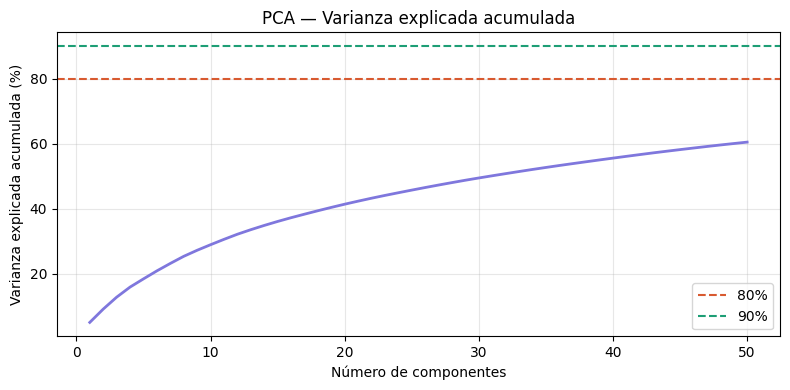

In [ ]:
import os
import numpy as np
os.makedirs("data/processed", exist_ok=True)

# Guardar embeddings
np.save("data/processed/embeddings.npy", embeddings)
print("Embeddings guardados.")

# PCA a 50 componentes para modelado
pca_50 = PCA(n_components=50, random_state=42)
embeddings_pca50 = pca_50.fit_transform(embeddings)
varianza_acumulada = np.cumsum(pca_50.explained_variance_ratio_) * 100

print(f"\nVarianza explicada acumulada:")
print(f"  10 componentes: {varianza_acumulada[9]:.1f}%")
print(f"  20 componentes: {varianza_acumulada[19]:.1f}%")
print(f"  50 componentes: {varianza_acumulada[49]:.1f}%")

# PCA a 2 componentes para visualización
pca_2 = PCA(n_components=2, random_state=42)
embeddings_2d = pca_2.fit_transform(embeddings)
df["pca_x"] = embeddings_2d[:, 0]
df["pca_y"] = embeddings_2d[:, 1]

print(f"\nVarianza con 2 componentes: {sum(pca_2.explained_variance_ratio_)*100:.1f}%")

# Curva de varianza
plt.figure(figsize=(8, 4))
plt.plot(range(1, 51), varianza_acumulada, color="#7F77DD", linewidth=2)
plt.axhline(y=80, color="#D85A30", linestyle="--", label="80%")
plt.axhline(y=90, color="#1D9E75", linestyle="--", label="90%")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada (%)")
plt.title("PCA — Varianza explicada acumulada")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
os.makedirs("reports", exist_ok=True)
plt.savefig("reports/pca_varianza.png", dpi=150, bbox_inches="tight")
plt.show()

#Normalizar

In [ ]:
from sklearn.preprocessing import StandardScaler

# Features numéricas a combinar
features_numericas = ["stars", "forks", "dias_sin_commit",
                      "antiguedad_dias", "num_topics",
                      "ratio_forks_stars", "stars_por_dia"]

# Normalizar
scaler = StandardScaler()
features_scaled = scaler.fit_transform(df[features_numericas])

print(f"Features numéricas normalizadas: {features_scaled.shape}")

# Combinar embeddings PCA50 + numéricas
features_combinadas = np.hstack([embeddings_pca50, features_scaled])
print(f"Shape features combinadas: {features_combinadas.shape}")

# Guardar todo
np.save("data/processed/features_combinadas.npy", features_combinadas)
np.save("data/processed/embeddings_pca50.npy", embeddings_pca50)
df.to_csv("data/processed/repos_clean.csv", index=False)

print("\nTodo guardado correctamente.")
print(f"  embeddings.npy         → (3034, 384)")
print(f"  embeddings_pca50.npy   → {embeddings_pca50.shape}")
print(f"  features_combinadas.npy→ {features_combinadas.shape}")
print(f"  repos_clean.csv        → {df.shape}")

Features numéricas normalizadas: (3034, 7)
Shape features combinadas: (3034, 57)

Todo guardado correctamente.
  embeddings.npy         → (3034, 384)
  embeddings_pca50.npy   → (3034, 50)
  features_combinadas.npy→ (3034, 57)
  repos_clean.csv        → (3034, 17)


#Graficas los clusteres

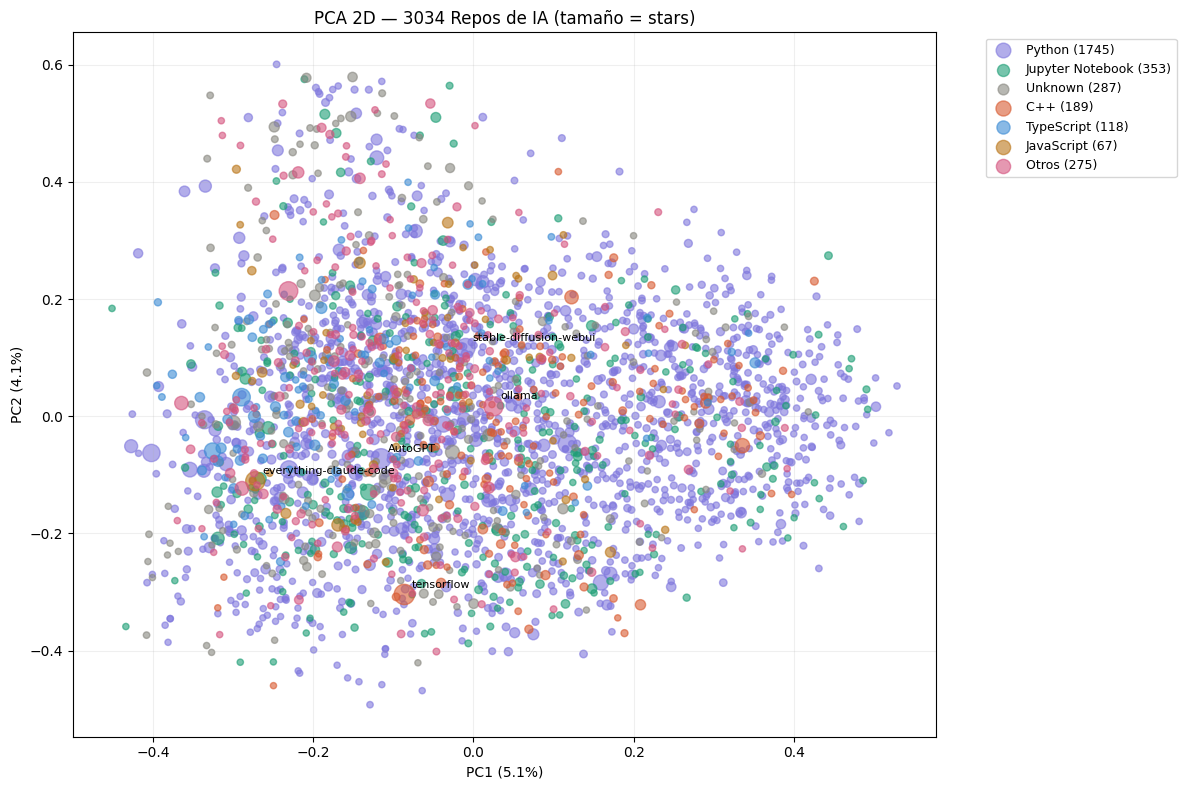

Guardado en reports/pca_2d.png


In [ ]:
plt.figure(figsize=(12, 8))

# Colorear por lenguaje dominante (top 6 + otros)
top_langs = df["lenguaje"].value_counts().head(6).index.tolist()
df["lang_plot"] = df["lenguaje"].apply(lambda x: x if x in top_langs else "Otros")

colores = {
    "Python": "#7F77DD",
    "Jupyter Notebook": "#1D9E75",
    "Unknown": "#888780",
    "C++": "#D85A30",
    "TypeScript": "#3B8BD4",
    "JavaScript": "#BA7517",
    "Otros": "#D4537E"
}

for lang, color in colores.items():
    mask = df["lang_plot"] == lang
    if mask.sum() == 0:
        continue
    plt.scatter(
        df[mask]["pca_x"],
        df[mask]["pca_y"],
        label=f"{lang} ({mask.sum()})",
        color=color,
        alpha=0.6,
        s=df[mask]["stars"] / 1000 + 20
    )

# Anotar top 5 repos
top5 = df.nlargest(5, "stars")
for _, row in top5.iterrows():
    plt.annotate(
        row["nombre"].split("/")[1],
        (row["pca_x"], row["pca_y"]),
        fontsize=8,
        xytext=(5, 5),
        textcoords="offset points",
        color="black"
    )

plt.xlabel(f"PC1 ({pca_2.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca_2.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA 2D — 3034 Repos de IA (tamaño = stars)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("reports/pca_2d.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado en reports/pca_2d.png")

#Encoding categórico de topics y lenguaje

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer
import ast

# Encoding de lenguaje (one-hot)
lenguaje_dummies = pd.get_dummies(df["lenguaje"], prefix="lang").astype(int)
print(f"Lenguaje encoding shape: {lenguaje_dummies.shape}")

# Encoding de topics (multi-label binarizer)
# topics está guardado como string, necesitamos convertirlo a lista
df["topics_list"] = df["topics"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Tomar solo los 30 topics más frecuentes
from collections import Counter
todos_topics = [t for topics in df["topics_list"] for t in topics]
top_topics = [t for t, _ in Counter(todos_topics).most_common(30)]

mlb = MultiLabelBinarizer(classes=top_topics)
topics_encoded = pd.DataFrame(
    mlb.fit_transform(df["topics_list"]),
    columns=[f"topic_{t}" for t in top_topics]
)
print(f"Topics encoding shape: {topics_encoded.shape}")
print(f"\nTop 10 topics más frecuentes:")
print(pd.Series(todos_topics).value_counts().head(10))

Lenguaje encoding shape: (3034, 41)
Topics encoding shape: (3034, 30)

Top 10 topics más frecuentes:
deep-learning            915
machine-learning         729
pytorch                  620
python                   439
llm                      425
computer-vision          347
ai                       340
tensorflow               285
nlp                      282
large-language-models    231
Name: count, dtype: int64


#Combinamos todo en una feature matrix completa

In [ ]:
# Reset index para asegurar alineación
lenguaje_dummies = lenguaje_dummies.reset_index(drop=True)
topics_encoded = topics_encoded.reset_index(drop=True)

# Feature matrix completa
# embeddings PCA50 + numéricas + lenguaje + topics
features_completas = np.hstack([
    embeddings_pca50,           # 50 semánticas
    features_scaled,            # 7 numéricas normalizadas
    lenguaje_dummies.values,    # 41 lenguajes
    topics_encoded.values       # 30 topics
])

print(f"Feature matrix completa: {features_completas.shape}")
print(f"  50 embeddings PCA")
print(f"  7  numéricas normalizadas")
print(f"  41 lenguajes one-hot")
print(f"  30 topics multi-label")
print(f"  Total: {features_completas.shape[1]} features por repo")

# Guardar
np.save("data/processed/features_completas.npy", features_completas)
print("\nGuardado en data/processed/features_completas.npy")

Feature matrix completa: (3034, 128)
  50 embeddings PCA
  7  numéricas normalizadas
  41 lenguajes one-hot
  30 topics multi-label
  Total: 128 features por repo

Guardado en data/processed/features_completas.npy


#Reporte semana 5

In [ ]:
print("=" * 55)
print("REPORTE SEMANA 5 — Representación y Dimensionalidad")
print("=" * 55)

print("\n1. FEATURE MATRICES CONSTRUIDAS")
print(f"   Texto (embeddings originales): (3034, 384)")
print(f"   Texto (embeddings PCA50):      (3034, 50)  — 60.5% varianza")
print(f"   Numéricas normalizadas:        (3034, 7)")
print(f"   Categóricas lenguaje:          (3034, 41)")
print(f"   Categóricas topics:            (3034, 30)")
print(f"   COMBINADA FINAL:               (3034, 128)")

print("\n2. DIMENSIONALITY REDUCTION — PCA")
print(f"   2  componentes: 9.2%  varianza — solo visualización")
print(f"   10 componentes: 29.0% varianza")
print(f"   20 componentes: 41.4% varianza")
print(f"   50 componentes: 60.5% varianza — usado para modelado")

print("\n3. INTERPRETACIÓN TÉCNICA")
print("   El espacio semántico es altamente dimensional.")
print("   Con 3034 repos diversos se necesitan 50 componentes")
print("   para capturar 60.5% de varianza — señal de riqueza")
print("   temática en el dataset, no de mala representación.")
print("   Topics más frecuentes: deep-learning (915), ")
print("   machine-learning (729), pytorch (620).")
print("   Python domina con 1747 repos de 3034.")

print("\n4. ARCHIVOS GUARDADOS")
print("   data/processed/embeddings.npy          (3034, 384)")
print("   data/processed/embeddings_pca50.npy    (3034, 50)")
print("   data/processed/features_combinadas.npy (3034, 57)")
print("   data/processed/features_completas.npy  (3034, 128)")
print("   data/processed/repos_clean.csv         (3034, 17)")
print("   reports/pca_varianza.png")
print("   reports/pca_2d.png")

REPORTE SEMANA 5 — Representación y Dimensionalidad

1. FEATURE MATRICES CONSTRUIDAS
   Texto (embeddings originales): (3034, 384)
   Texto (embeddings PCA50):      (3034, 50)  — 60.5% varianza
   Numéricas normalizadas:        (3034, 7)
   Categóricas lenguaje:          (3034, 41)
   Categóricas topics:            (3034, 30)
   COMBINADA FINAL:               (3034, 128)

2. DIMENSIONALITY REDUCTION — PCA
   2  componentes: 9.2%  varianza — solo visualización
   10 componentes: 29.0% varianza
   20 componentes: 41.4% varianza
   50 componentes: 60.5% varianza — usado para modelado

3. INTERPRETACIÓN TÉCNICA
   El espacio semántico es altamente dimensional.
   Con 3034 repos diversos se necesitan 50 componentes
   para capturar 60.5% de varianza — señal de riqueza
   temática en el dataset, no de mala representación.
   Topics más frecuentes: deep-learning (915), 
   machine-learning (729), pytorch (620).
   Python domina con 1747 repos de 3034.

4. ARCHIVOS GUARDADOS
   data/processed/